# Chapters 1 & 2 — Intensity Trends and Communication Positioning

Covers:
- **Ch. 1**: AI mention intensity over time by industry
- **Ch. 2/3**: D3 Technical Specificity vs D7 Promotional Tone positioning map

**Requires:** `clustering_archetypes.ipynb` must have been run first.

In [8]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
DATA = Path('../data')

clusters = pd.read_parquet(DATA / 'processed/clusters/firm_year_clusters.parquet')
features = pd.read_parquet(DATA / 'processed/features/firm_year_features.parquet')

df = clusters.merge(
    features[['ticker','year','ai_mentions_count','industry_group']],
    on=['ticker','year'], how='left', suffixes=('','_feat')
)
print(f'Loaded: {df.shape}')
print(f'Years: {sorted(df["year"].unique())}')


Loaded: (658, 24)
Years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## Ch. 1 — AI Mention Intensity Over Time

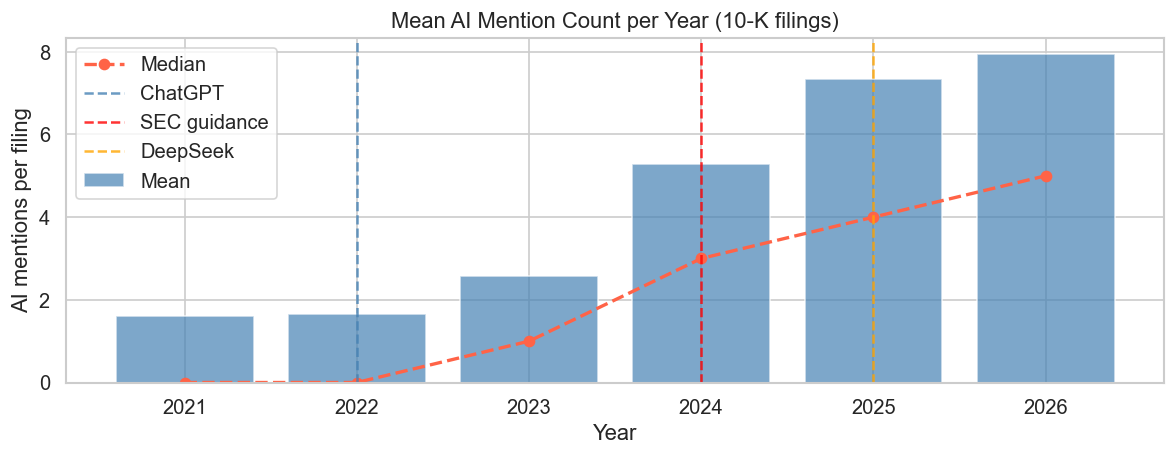

In [9]:
EVENTS = {2022: ('ChatGPT', 'steelblue'), 2024: ('SEC guidance', 'red'), 2025: ('DeepSeek', 'orange')}
Path('../reports').mkdir(exist_ok=True)

# 1a. Overall AI mention count per year
yr = features.groupby('year')['ai_mentions_count'].agg(['mean','median']).reset_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yr['year'], yr['mean'], color='steelblue', alpha=0.7, label='Mean')
ax.plot(yr['year'], yr['median'], 'o--', color='tomato', linewidth=2, label='Median')
for yr_ev, (label, color) in EVENTS.items():
    ax.axvline(yr_ev, color=color, linestyle='--', linewidth=1.5, alpha=0.8, label=label)
ax.set_xlabel('Year'); ax.set_ylabel('AI mentions per filing')
ax.set_title('Mean AI Mention Count per Year (10-K filings)')
ax.set_xticks(yr['year'])
ax.legend()
plt.tight_layout()
plt.savefig('../reports/ai_intensity_by_year.png', dpi=150, bbox_inches='tight')
plt.show()


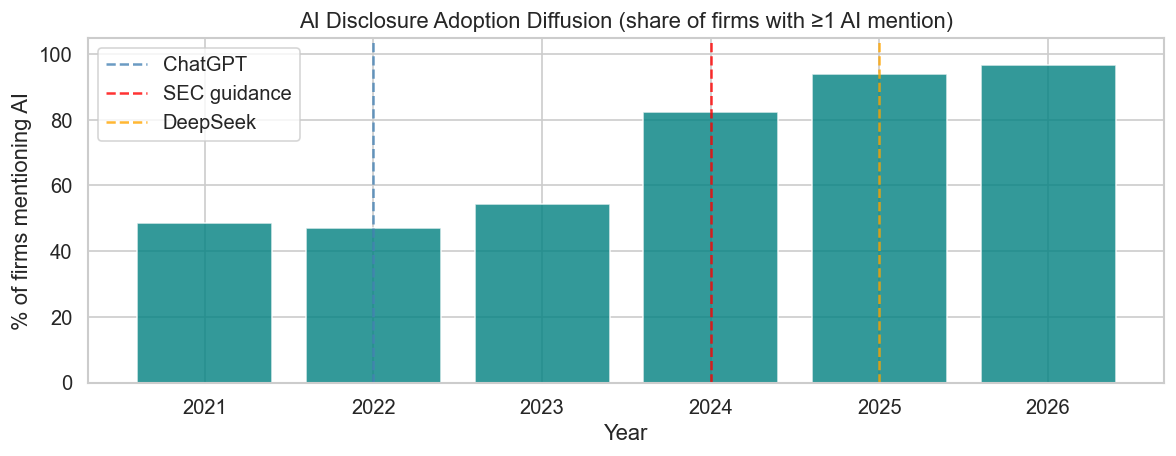

 year  pct_disclosing  n_firms
 2021       48.648649    111.0
 2022       46.902655    113.0
 2023       54.385965    114.0
 2024       82.456140    114.0
 2025       93.913043    115.0
 2026       96.703297     91.0


In [10]:
# 1b. Share of firms disclosing AI each year
disc = (
    features.groupby('year')
    .apply(lambda g: pd.Series({
        'pct_disclosing': (g['ai_mentions_count'] > 0).mean() * 100,
        'n_firms': g['ticker'].nunique()
    }))
    .reset_index()
)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(disc['year'], disc['pct_disclosing'], color='teal', alpha=0.8)
for yr_ev, (label, color) in EVENTS.items():
    ax.axvline(yr_ev, color=color, linestyle='--', linewidth=1.5, alpha=0.8, label=label)
ax.set_ylim(0, 105)
ax.set_xlabel('Year'); ax.set_ylabel('% of firms mentioning AI')
ax.set_title('AI Disclosure Adoption Diffusion (share of firms with ≥1 AI mention)')
ax.set_xticks(disc['year'])
ax.legend()
plt.tight_layout()
plt.savefig('../reports/ai_adoption_share_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print(disc.to_string(index=False))


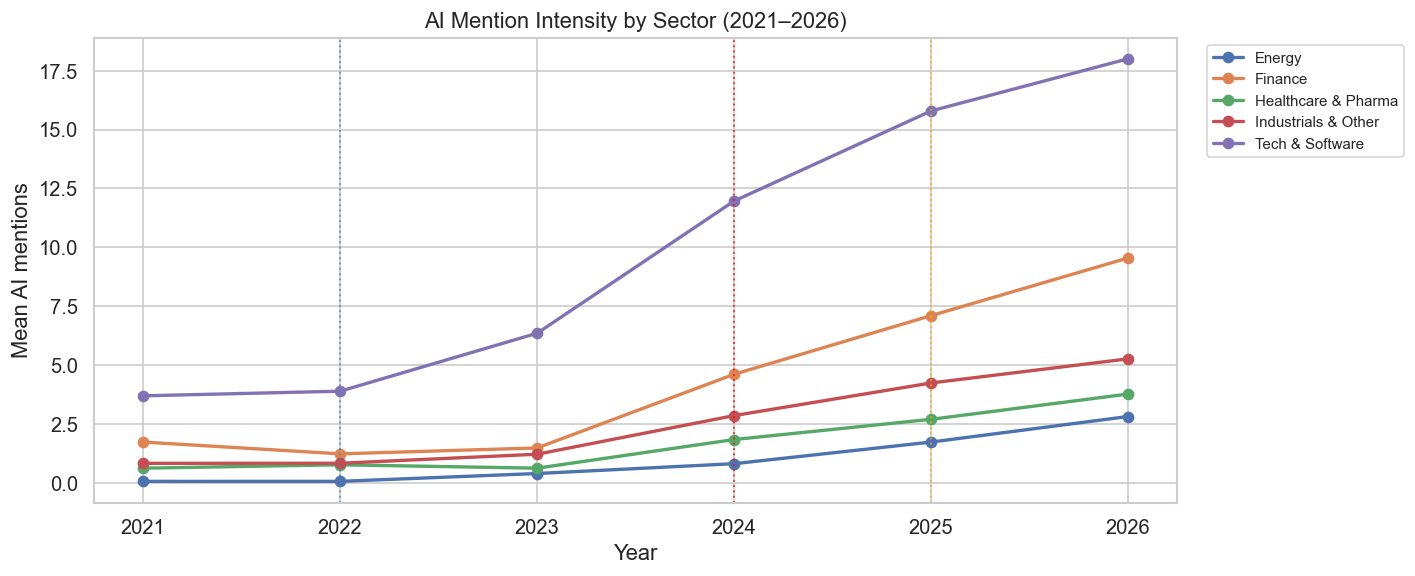

In [11]:
# 1c. AI mention intensity by top-level sector group over time
# Collapse SIC-level industry_group into 5 broad sectors for readability
SECTOR_MAP = {
    'Services-Prepackaged Software': 'Tech & Software',
    'Semiconductors & Related Devices': 'Tech & Software',
    'Electronic Computers': 'Tech & Software',
    'Computer Communications Equipment': 'Tech & Software',
    'Computer Peripheral Equipment, NEC': 'Tech & Software',
    'Services-Computer Programming, Data Processing, Etc.': 'Tech & Software',
    'Services-Computer Programming Services': 'Tech & Software',
    'Services-Business Services, NEC': 'Tech & Software',
    'Pharmaceutical Preparations': 'Healthcare & Pharma',
    'Biological Products, (No Diagnostic Substances)': 'Healthcare & Pharma',
    'Surgical & Medical Instruments & Apparatus': 'Healthcare & Pharma',
    'Orthopedic, Prosthetic & Surgical Appliances & Supplies': 'Healthcare & Pharma',
    'Petroleum Refining': 'Energy',
    'Crude Petroleum & Natural Gas': 'Energy',
    'Oil & Gas Field Services, NEC': 'Energy',
    'Electric Services': 'Energy',
    'Electric & Other Services Combined': 'Energy',
    'Gas & Other Services Combined': 'Energy',
    'National Commercial Banks': 'Finance',
    'Security Brokers, Dealers & Flotation Companies': 'Finance',
    'Finance Services': 'Finance',
}
features['sector'] = features['industry_group'].map(SECTOR_MAP).fillna('Industrials & Other')

sec_yr = features.groupby(['year','sector'])['ai_mentions_count'].mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
for sector, grp in sec_yr.groupby('sector'):
    grp = grp.sort_values('year')
    ax.plot(grp['year'], grp['ai_mentions_count'], marker='o', linewidth=2, label=sector)
for yr_ev, (label, color) in EVENTS.items():
    ax.axvline(yr_ev, color=color, linestyle=':', linewidth=1.2, alpha=0.7)
ax.set_xlabel('Year'); ax.set_ylabel('Mean AI mentions')
ax.set_title('AI Mention Intensity by Sector (2021–2026)')
ax.set_xticks(sorted(sec_yr['year'].unique()))
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/ai_intensity_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()


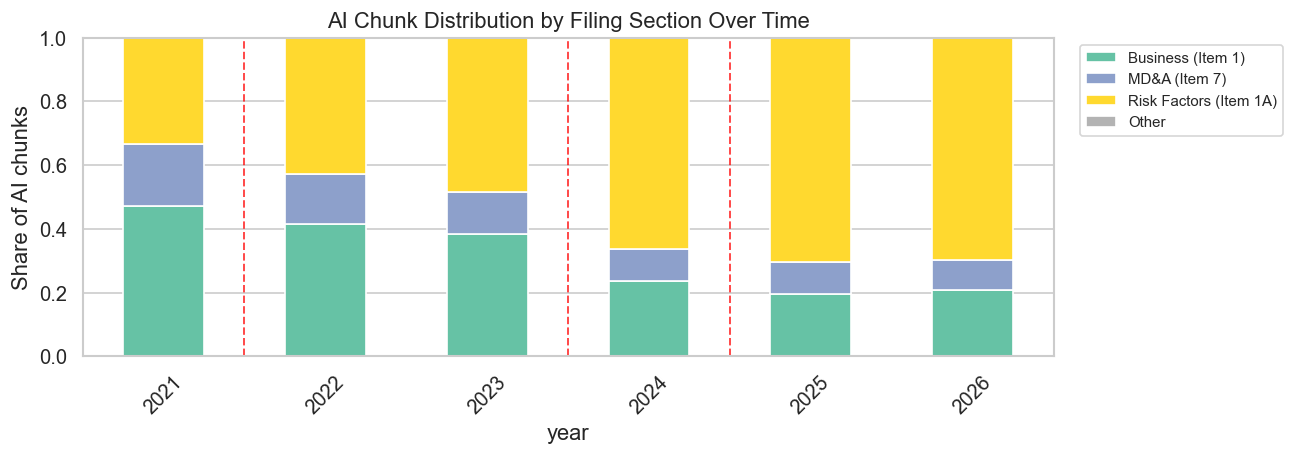

In [13]:
# 1d. Section distribution over time
sec_cols = ['sec_pct_business', 'sec_pct_mda', 'sec_pct_risk_factors', 'sec_pct_other']
sec_yr2 = features[features['ai_mentions_count'] > 0].groupby('year')[sec_cols].mean()
sec_yr2.columns = ['Business (Item 1)', 'MD&A (Item 7)', 'Risk Factors (Item 1A)', 'Other']
sec_yr2.plot(kind='bar', stacked=True, figsize=(11, 4), colormap='Set2')
for i, yr_ev in enumerate([2022, 2024, 2025]):
    years_list = list(sec_yr2.index)
    if yr_ev in years_list:
        plt.axvline(years_list.index(yr_ev) - 0.5, color='red', linestyle='--',
                    linewidth=1.2, alpha=0.7)
plt.ylabel('Share of AI chunks')
plt.title('AI Chunk Distribution by Filing Section Over Time')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/section_distribution_by_year.png', dpi=150, bbox_inches='tight')
plt.show()


## Ch. 2/3 — Communication Positioning Map (D3 Technical × D7 Promotional)

D3=D3 Technical  D7=D7 Promotional  D1=D1 AI Intensity


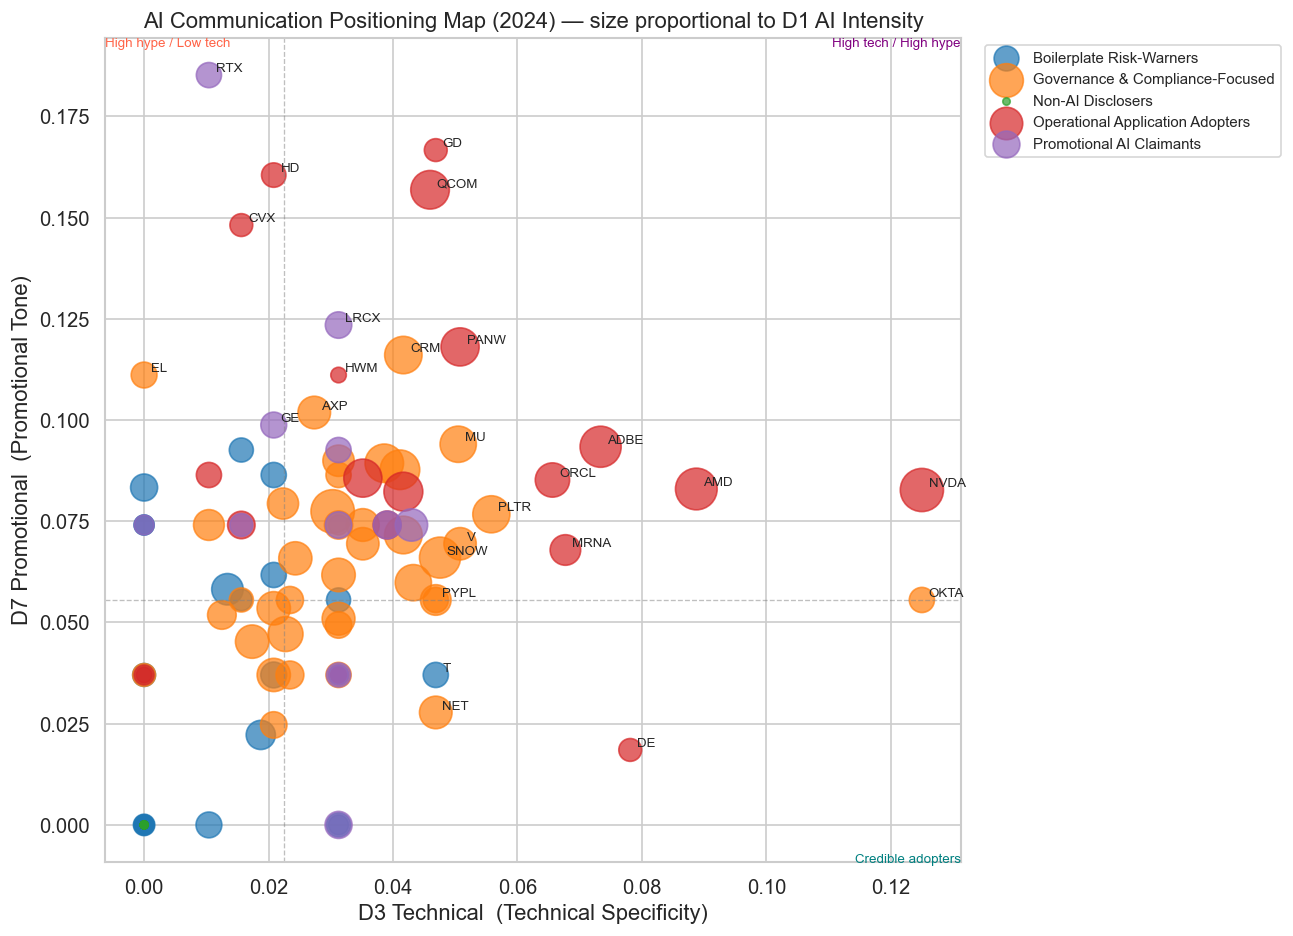

In [14]:
DIM_COLS = [c for c in clusters.columns if c.startswith('D') and c[1].isdigit()]
d3_col = next((c for c in DIM_COLS if 'Technical' in c), None)
d7_col = next((c for c in DIM_COLS if 'Promotional' in c), None)
d1_col = next((c for c in DIM_COLS if 'Intensity' in c), None)
print(f'D3={d3_col}  D7={d7_col}  D1={d1_col}')

archetype_colors = {
    a: c for a, c in zip(
        sorted(clusters['cluster_name'].unique()),
        sns.color_palette('tab10', clusters['cluster_name'].nunique())
    )
}

df_2024 = clusters[clusters['year'] == 2024].copy()

fig, ax = plt.subplots(figsize=(11, 8))
for name, grp in df_2024.groupby('cluster_name'):
    size = (grp[d1_col] * 300 + 20) if d1_col else 60
    ax.scatter(grp[d3_col], grp[d7_col], s=size, alpha=0.7,
               label=name, color=archetype_colors[name])

df_2024['d3_rank'] = df_2024[d3_col].rank(pct=True)
df_2024['d7_rank'] = df_2024[d7_col].rank(pct=True)
label_mask = (df_2024['d3_rank'] > 0.88) | (df_2024['d7_rank'] > 0.88)
for _, row in df_2024[label_mask].iterrows():
    ax.annotate(row['ticker'], (row[d3_col], row[d7_col]),
                fontsize=8, ha='left', xytext=(4, 2), textcoords='offset points')

ax.axhline(df_2024[d7_col].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(df_2024[d3_col].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

xlim, ylim = ax.get_xlim(), ax.get_ylim()
ax.text(xlim[0], ylim[1], 'High hype / Low tech', fontsize=8, color='tomato', va='top')
ax.text(xlim[1], ylim[1], 'High tech / High hype', fontsize=8, color='purple', va='top', ha='right')
ax.text(xlim[1], ylim[0], 'Credible adopters', fontsize=8, color='teal', ha='right')

ax.set_xlabel(str(d3_col) + '  (Technical Specificity)')
ax.set_ylabel(str(d7_col) + '  (Promotional Tone)')
ax.set_title('AI Communication Positioning Map (2024) — size proportional to D1 AI Intensity')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/positioning_map_2024.png', dpi=150, bbox_inches='tight')
plt.show()


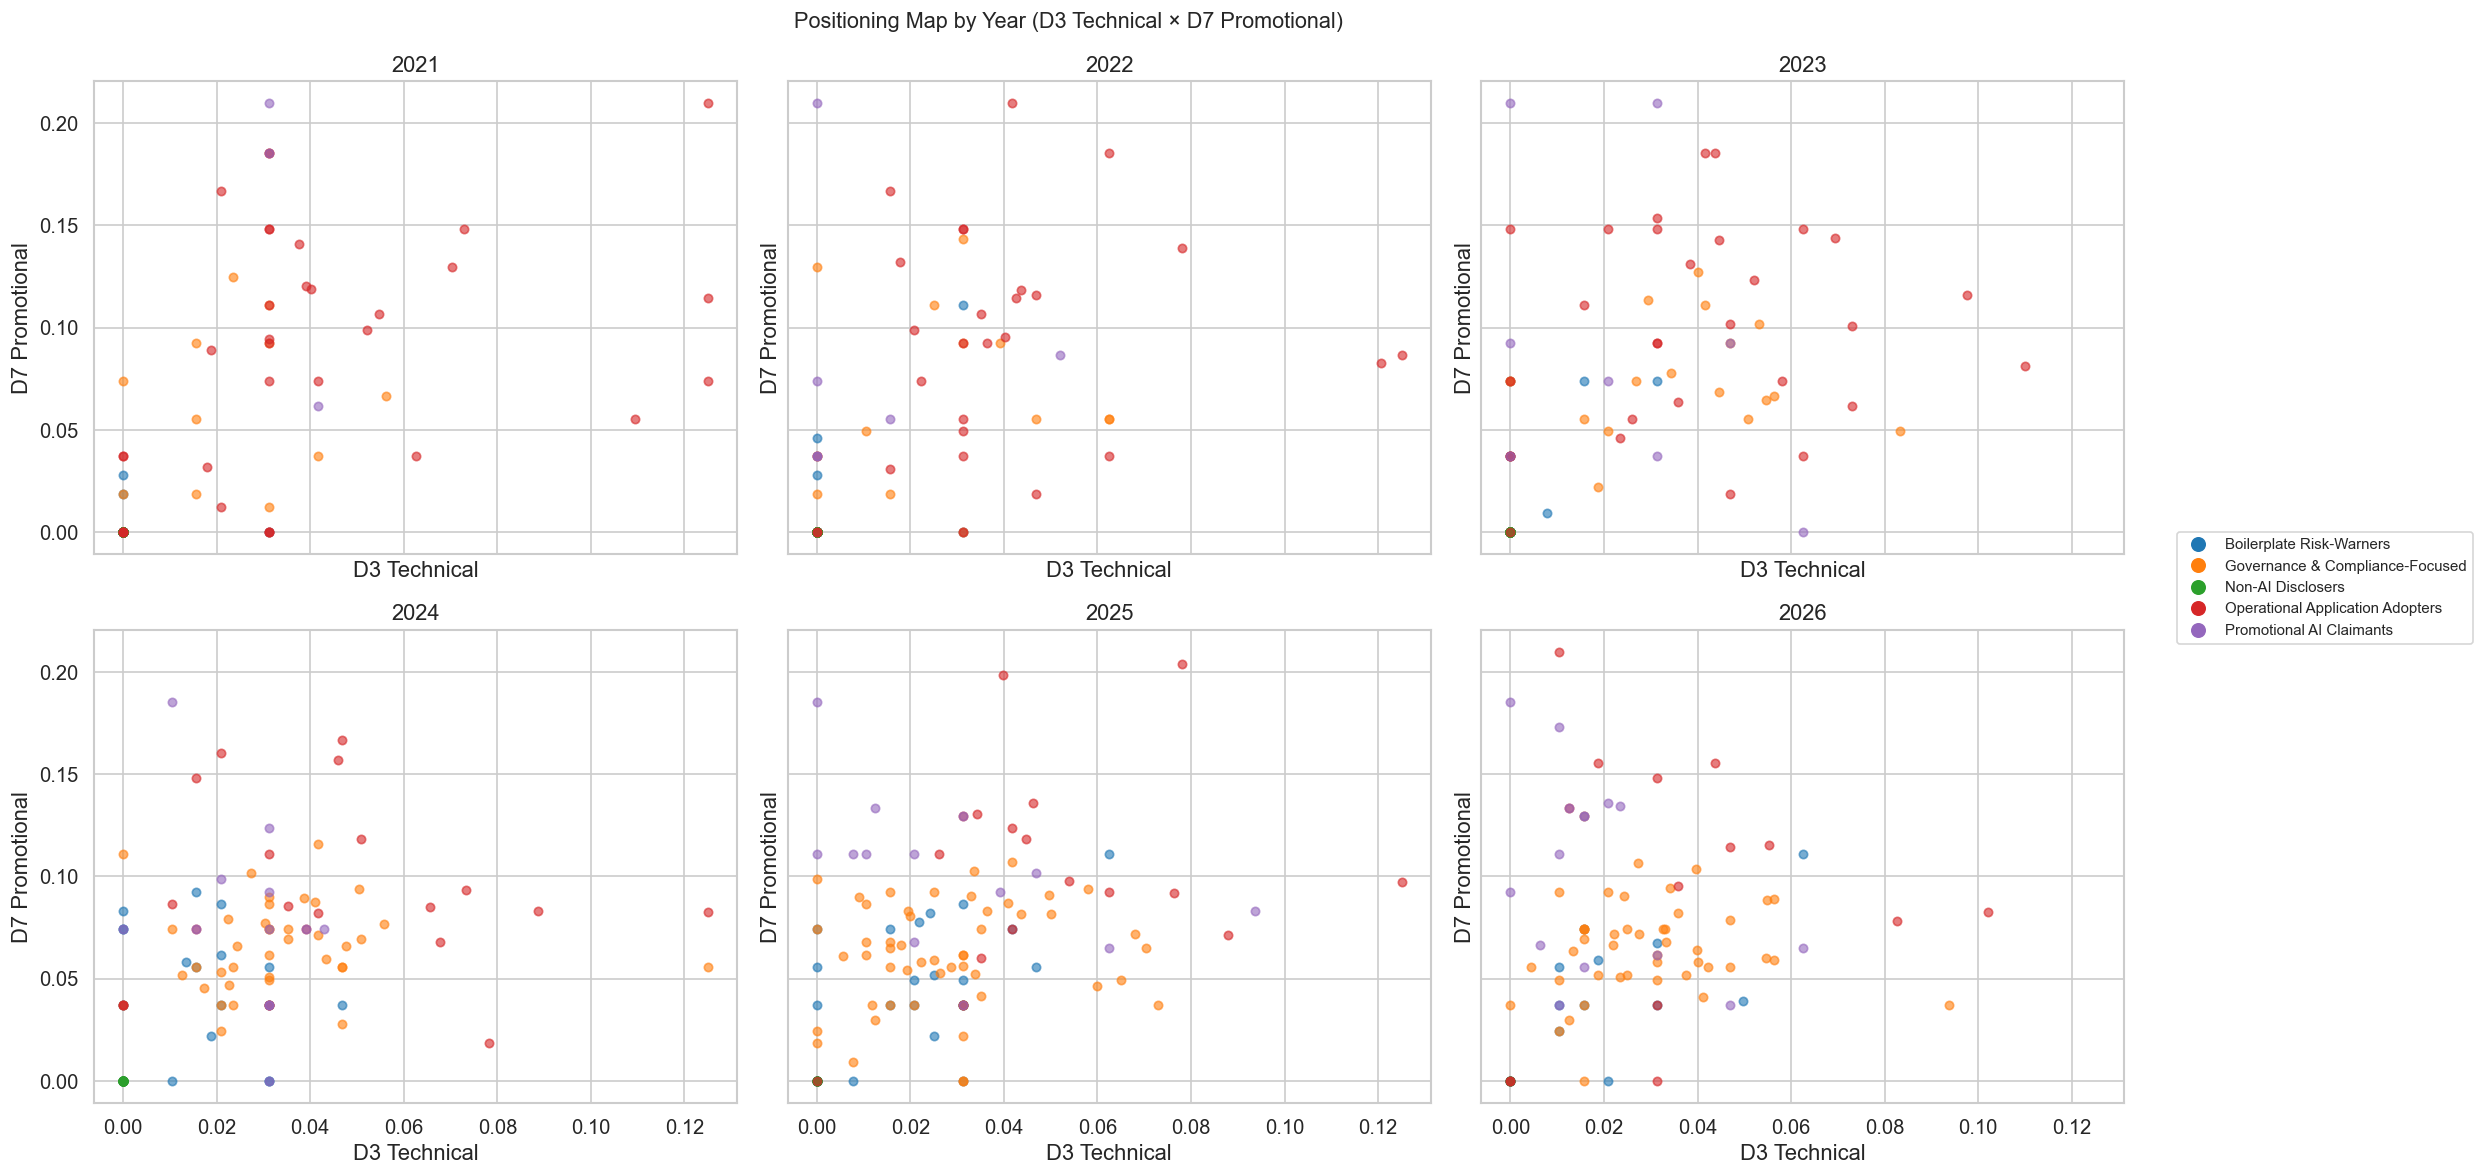

In [15]:
# Positioning map over all years — faceted by year
years = sorted(clusters['year'].unique())
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, yr in zip(axes.flat, years):
    sub = clusters[clusters['year'] == yr]
    for name, grp in sub.groupby('cluster_name'):
        ax.scatter(grp[d3_col], grp[d7_col], s=25, alpha=0.6,
                   label=name, color=archetype_colors[name])
    ax.set_title(str(yr))
    ax.set_xlabel('D3 Technical')
    ax.set_ylabel('D7 Promotional')

handles = [plt.Line2D([0],[0], marker='o', linestyle='', color=c, label=a, markersize=8)
           for a, c in archetype_colors.items()]
fig.legend(handles=handles, bbox_to_anchor=(1.01, 0.5), loc='center left', fontsize=9)
fig.suptitle('Positioning Map by Year (D3 Technical × D7 Promotional)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/positioning_map_by_year.png', dpi=150, bbox_inches='tight')
plt.show()


## Section Location Distribution per Archetype

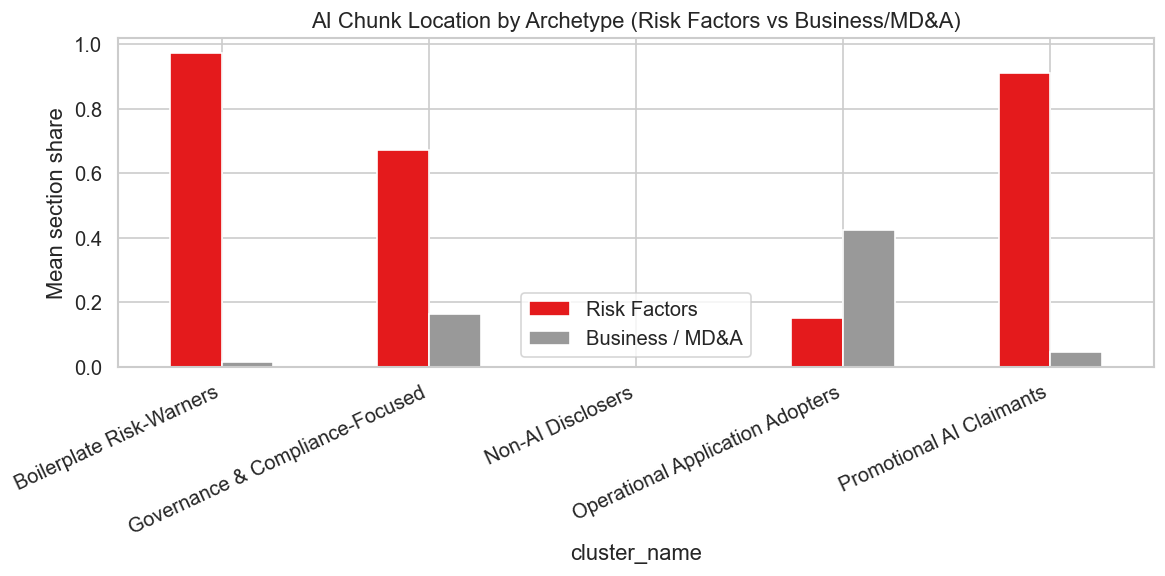

                                  Risk Factors  Business / MD&A
cluster_name                                                   
Boilerplate Risk-Warners                 0.972            0.014
Governance & Compliance-Focused          0.672            0.164
Non-AI Disclosers                        0.000            0.000
Operational Application Adopters         0.153            0.424
Promotional AI Claimants                 0.910            0.045


In [16]:
sec_cols_disp = {
    'D9 Risk-section': 'Risk Factors',
    'D9 Substantive-section': 'Business / MD&A',
}
avail = {k: v for k, v in sec_cols_disp.items() if k in clusters.columns}

sec_by_arch = clusters.groupby('cluster_name')[list(avail.keys())].mean()
sec_by_arch.columns = list(avail.values())

sec_by_arch.plot(kind='bar', figsize=(10, 5), colormap='Set1', edgecolor='white')
plt.ylabel('Mean section share')
plt.title('AI Chunk Location by Archetype (Risk Factors vs Business/MD&A)')
plt.xticks(rotation=25, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/section_by_archetype.png', dpi=150, bbox_inches='tight')
plt.show()
print(sec_by_arch.round(3).to_string())
